<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/MSc_Project_N1217583.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# For TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# For Grad-CAM
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K
import matplotlib.cm as cm

# For Image Utilities
from PIL import Image
import glob

# Connecting Drive
from google.colab import drive
drive.mount('/content/drive')
from collections import defaultdict

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
plantvillage_path = '/content/drive/MyDrive/Final Project Dataset/PlantVillage'

# Creating a dictionary to hold all image paths by class
dataset = defaultdict(list)

for class_name in os.listdir(plantvillage_path):
    class_path = os.path.join(plantvillage_path, class_name)
    if os.path.isdir(class_path):
        for image_file in os.listdir(class_path):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                dataset[class_name].append(os.path.join(class_path, image_file))

# Print summary
for class_name, images in dataset.items():
    print(f"{class_name}: {len(images)} images")

Tomato_Septoria_leaf_spot: 1771 images
Tomato_healthy: 1591 images
Tomato_Late_blight: 1909 images
Tomato_Leaf_Mold: 952 images
Tomato_Early_blight: 1000 images


In [3]:
# Creating a dictionary to hold all image paths by class
dataset = defaultdict(list)

for class_name in os.listdir(plantvillage_path):
    class_path = os.path.join(plantvillage_path, class_name)
    if os.path.isdir(class_path):
        for image_file in os.listdir(class_path):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                dataset[class_name].append(os.path.join(class_path, image_file))

In [4]:
# Creating a dictionary to hold all image paths by class
dataset = defaultdict(list)

max_images_per_class = 900

for class_name in os.listdir(plantvillage_path):
    class_path = os.path.join(plantvillage_path, class_name)
    if os.path.isdir(class_path):
        # Creating a list to hold image files for the current class
        current_class_image_files = []
        for image_file in os.listdir(class_path):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                current_class_image_files.append(os.path.join(class_path, image_file))

        import random
        # Shuffle the list of image files for the current class
        random.shuffle(current_class_image_files)
        # Assign the shuffled and truncated list to the dataset dictionary
        dataset[class_name] = current_class_image_files[:max_images_per_class]


# summary
for class_name, images in dataset.items():
    # Use max_images_per_class in the print statement for clarity
    print(f"{class_name}: {len(images)} images (max {max_images_per_class} used)")

Tomato_Septoria_leaf_spot: 900 images (max 900 used)
Tomato_healthy: 900 images (max 900 used)
Tomato_Late_blight: 900 images (max 900 used)
Tomato_Leaf_Mold: 900 images (max 900 used)
Tomato_Early_blight: 900 images (max 900 used)


#  1. Visualizing Some Sample Images

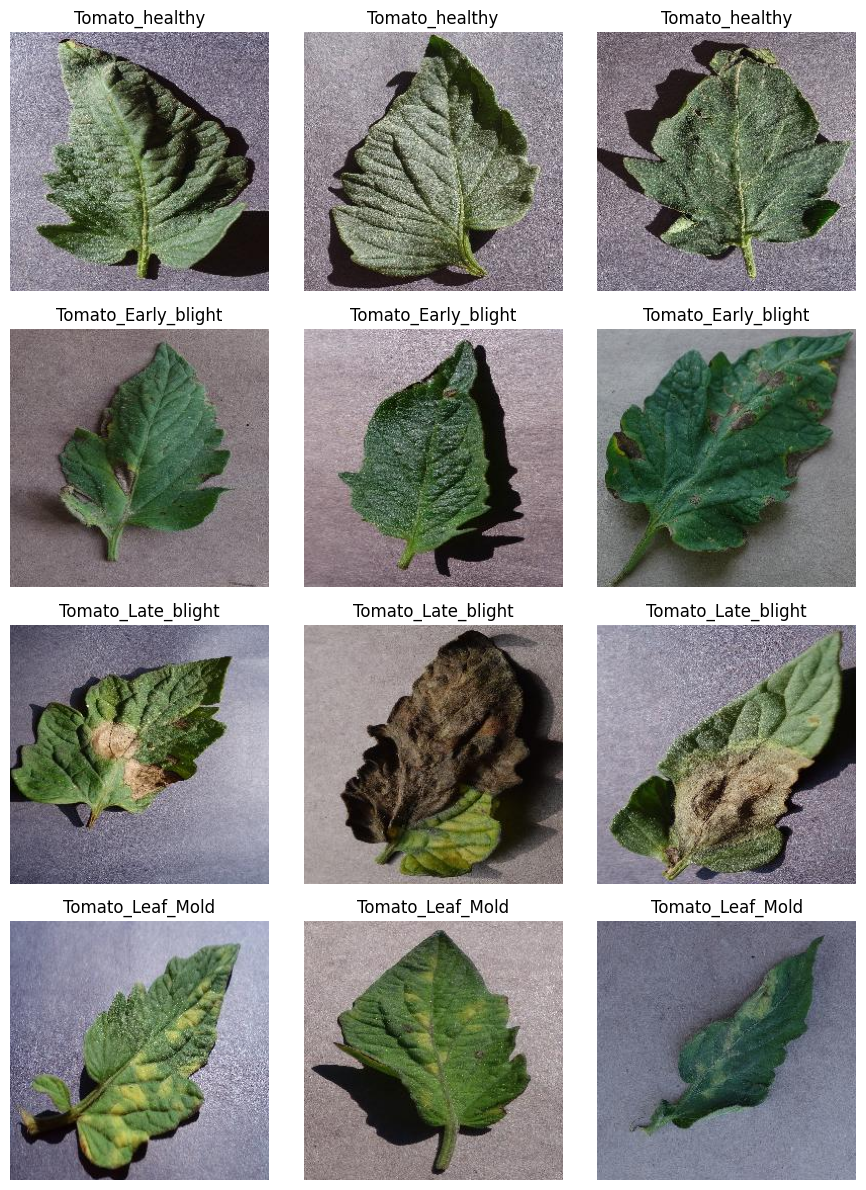

In [ ]:
import matplotlib.pyplot as plt
import random

# Display sample images from random classes
def show_sample_images(dataset, num_classes=4, samples_per_class=3):
    class_names = list(dataset.keys())
    random.shuffle(class_names)
    selected_classes = class_names[:num_classes]

    plt.figure(figsize=(samples_per_class * 3, num_classes * 3))

    for i, class_name in enumerate(selected_classes):
        images = dataset[class_name]
        random.shuffle(images)
        for j in range(samples_per_class):
            img = cv2.imread(images[j])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(num_classes, samples_per_class, i * samples_per_class + j + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function
show_sample_images(dataset)

# 2. Preparing Images Paths for Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

image_paths = []
labels = []

for class_name, files in dataset.items():
    for file in files:
        image_paths.append(file)
        labels.append(class_name)

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

# Split the dataset
X_train, X_val, y_train, y_val = train_test_split(
    image_paths, encoded_labels, test_size=0.2, stratify=encoded_labels, random_state=42
)

print(f"Train samples: {len(X_train)} | Validation samples: {len(X_val)}")


Train samples: 3600 | Validation samples: 900


# 3. Use ImageDataGenerator for Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation set
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Train generator
train_generator = train_datagen.flow_from_directory(
    # Use the correct path to your dataset on Google Drive
    '/content/drive/MyDrive/Final Project Dataset/PlantVillage',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    # Use the correct path to your dataset on Google Drive
    '/content/drive/MyDrive/Final Project Dataset/PlantVillage',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Number of classes
num_classes = len(train_generator.class_indices)

Found 5780 images belonging to 5 classes.
Found 1443 images belonging to 5 classes.


# 4. Creating TensorFlow Dataset from Paths

In [ ]:
# Handles Data Loading Efficiently: Instead of loading all images into memory at once (which can be problematic for large datasets), this section creates a TensorFlow Dataset object. This object can efficiently load and process images on the fly as needed during training.

import tensorflow as tf

# Creating a TensorFlow Dataset object from image paths and labels
def process_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

# Wraping in tf.data.Dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

train_ds = train_ds.map(process_image).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(process_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 5. Building CNN Model (EfficientNetB0-based)

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import tensorflow as tf

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  #freez weights

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras import layers, Model, Input

inputs = Input(shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)

# Getting the number of classes from the fitted LabelEncoder
num_classes = len(le.classes_)


predictions = Dense(num_classes, activation='softmax')(x)  # Final layer

# Final model
model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              # Change the loss function to 'sparse_categorical_crossentropy'
              # to match the sparse integer labels.
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Set up EarlyStopping to prevent overfitting and unnecessary training
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 6. Training the Model

In [ ]:
# Train the model using early stopping
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 639s 4s/step - accuracy: 0.3651 - loss: 1.5585 - val_accuracy: 0.7644 - val_loss: 0.7582
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.6763 - loss: 0.8756 - val_accuracy: 0.8133 - val_loss: 0.5590
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.7599 - loss: 0.6566 - val_accuracy: 0.8456 - val_loss: 0.4638
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.7916 - loss: 0.5584 - val_accuracy: 0.8756 - val_loss: 0.4102
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.8240 - loss: 0.4955 - val_accuracy: 0.8744 - val_loss: 0.3859
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.8214 - loss: 0.4716 - val_accuracy: 0.8856 - val_loss: 0.3597
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.8483 - loss: 0.4122 - val_accuracy: 0.8978 - val_loss: 0.3299
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.8533 - loss: 0.3946 - val_accu

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9202 - loss: 0.2320
Validation Loss: 0.2337
Validation Accuracy: 0.9256


# 7. Plot Accuracy & Loss Curves

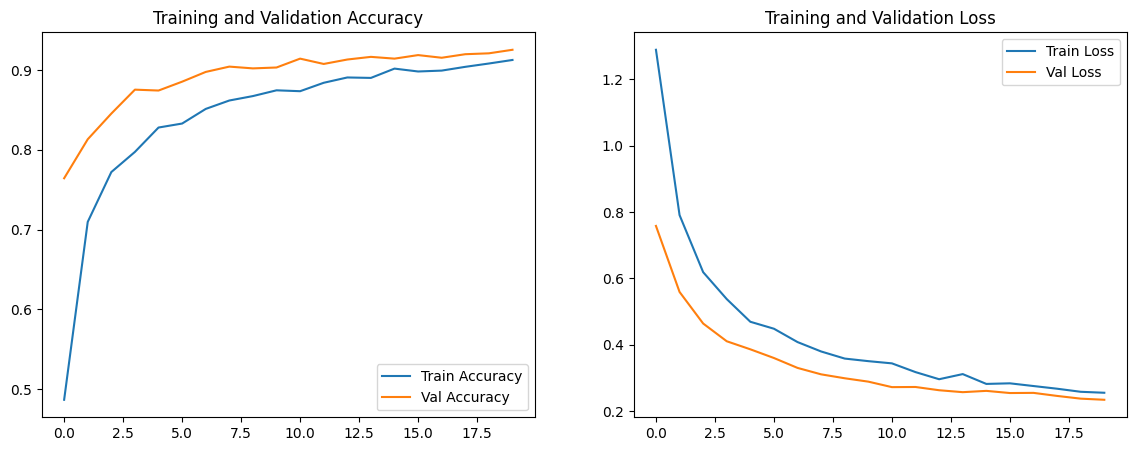

In [ ]:
import matplotlib.pyplot as plt

def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_training(history)

In [ ]:
# prompt: write a code to save te model in google drive

# Specify the path in your Google Drive where you want to save the model
model_save_path = '/content/drive/MyDrive/plant_disease_model.h5'

# Save the trained model
model.save(model_save_path)

print(f"Model saved successfully to: {model_save_path}")

Model saved successfully to: /content/drive/MyDrive/plant_disease_model.h5


# Confusion Matrix

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


46/46 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step


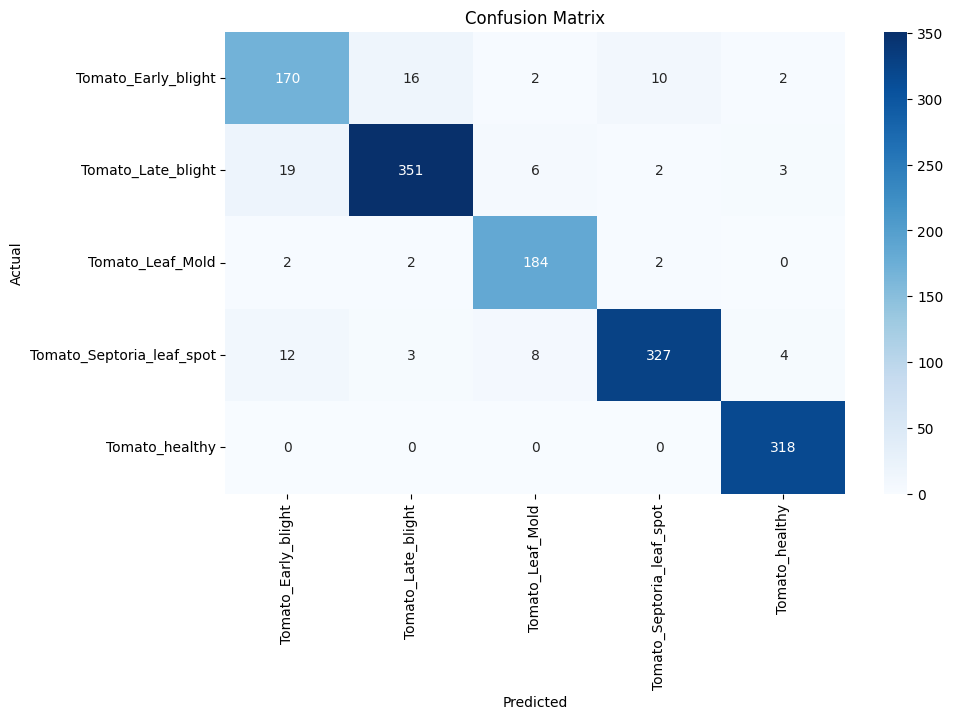

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Getting true labels and predictions
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

# Class labels:
class_names = list(val_generator.class_indices.keys())

# Computing confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Grad-CAM Visualization

In [5]:
# Loading the Trained Model:
model = load_model('/content/drive/MyDrive/plant_disease_model.h5')

# Choosing the PreProcessing Sample Image

In [6]:
# Loading and preprocess an image (update path)

img_path = '/content/drive/MyDrive/IMG_20191216_155825.jpg'
img_size = (224, 224)

img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Creating a Grad-CAM Heatmap Function

In [7]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Grad-CAM Heatmap and Overlay on Original Image function

Found last convolutional layer: Conv_1


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


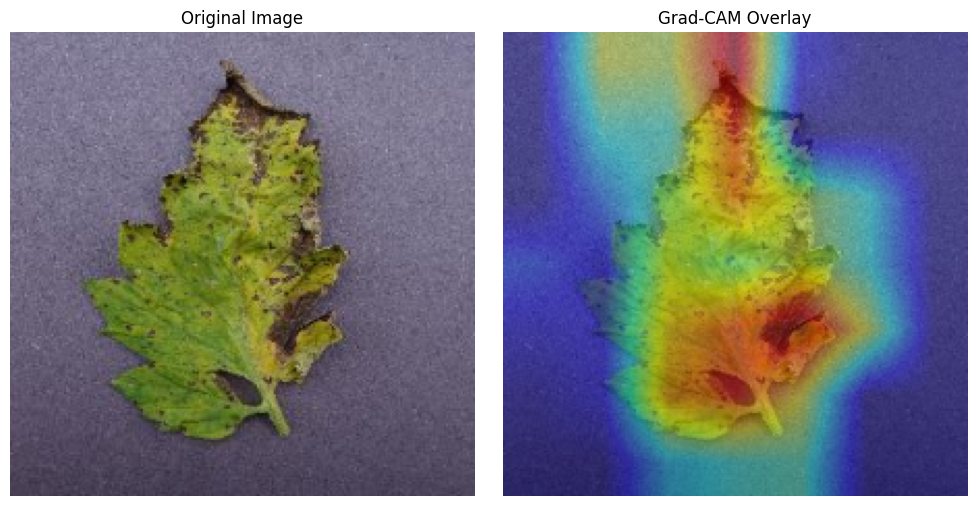

In [8]:
'''# Generating Heatmap and Overlay on Original Image

# Path to image
img_path = '/content/drive/MyDrive/Final Project Dataset/PlantVillage/Tomato_Septoria_leaf_spot/04840559-16ed-4f17-908b-2048ba83ab80___Keller.St_CG 1780.JPG'

# Load and preprocess image using cv2 for easier heatmap overlay later
img = cv2.imread(img_path)
# Ensure img is not None (check if image loading was successful)
if img is None:
    raise FileNotFoundError(f"Image not found at path: {img_path}")

img = cv2.resize(img, (224, 224))  # use your model's input size
# Expand dimensions and normalize for the model
img_array = np.expand_dims(img / 255.0, axis=0)

# Find the name of the last convolutional layer in the model
for layer in reversed(model.layers):
    if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D)):
        last_conv_layer_name = layer.name
        print(f"Found last convolutional layer: {last_conv_layer_name}")
        break


# Redefine the make_gradcam_heatmap function to work with the full model
# and the target layer name directly within the full model.
def make_gradcam_heatmap(img_array, full_model, target_layer_name, pred_index=None):
    # Getting the output of the target layer and the final model output
    grad_model = tf.keras.models.Model(
        [full_model.inputs],
        [full_model.get_layer(target_layer_name).output, full_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            # Finding the predicted class index
            pred_index = tf.argmax(predictions[0])
        # Getting the score for the predicted class
        class_channel = predictions[:, pred_index]

    # Computing the gradient of the predicted class score with respect to the convolutional layer output
    grads = tape.gradient(class_channel, conv_outputs)
    # Average the gradients over spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the convolutional layer output by the average gradient for that channel
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU to the heatmap and normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Generate heatmap
# Call the make_gradcam_heatmap function with the correct layer name
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Resize and color the heatmap
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

# Superimpose
# Convert img to float for calculation if it's not already
img_float = img.astype(np.float32)

# Overlay the heatmap on the original image
# Adjust the alpha values (0.4 and 0.6) to control transparency
superimposed_img = heatmap_colored * 0.4 + img_float * 0.6
# Clip values to the valid range [0, 255] and convert back to uint8
superimposed_img = np.uint8(np.clip(superimposed_img, 0, 255))

# Plot original and overlay
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM Overlay")
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()'''

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.wa

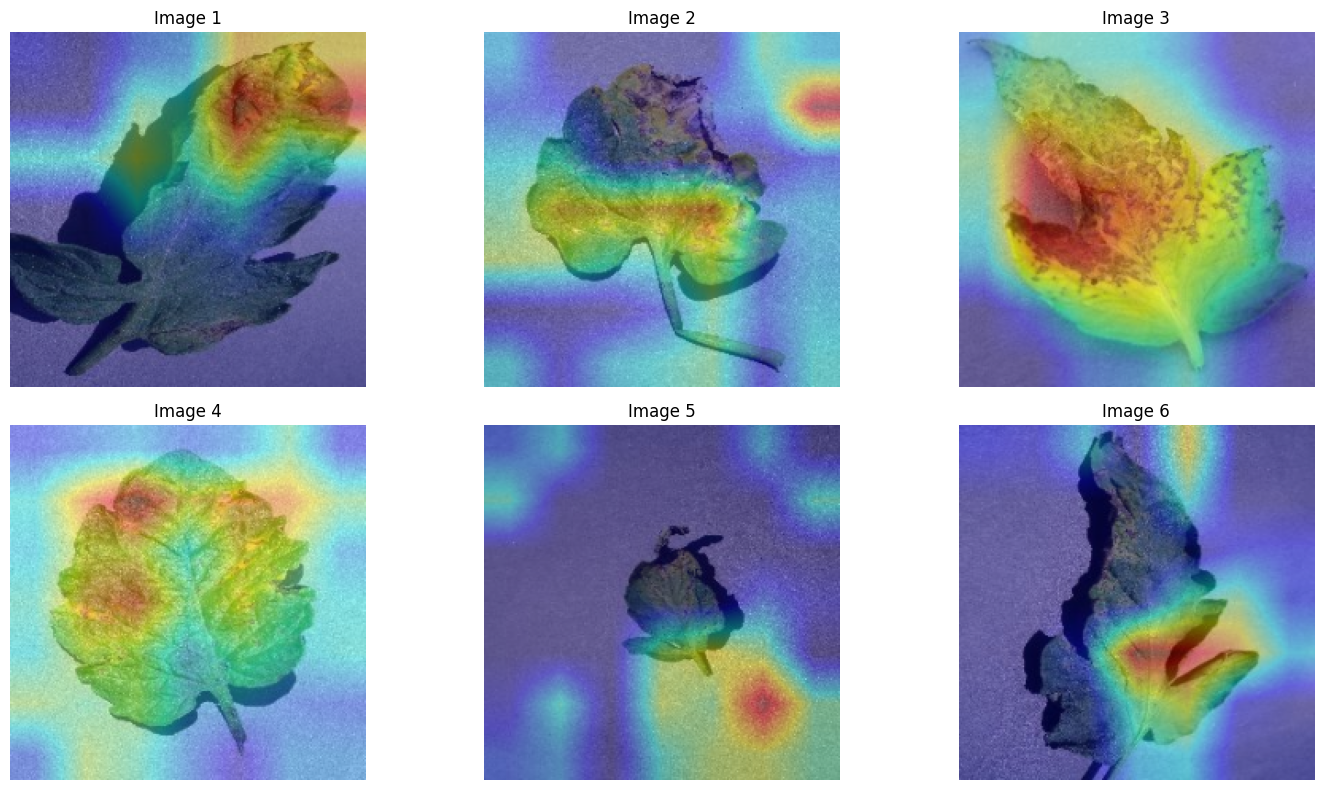

In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from glob import glob

# === Parameters ===
folder_path = '/content/drive/MyDrive/Final Project Dataset/PlantVillage/Tomato_Septoria_leaf_spot'
input_size = (224, 224)

# === Automatically find the last conv layer ===
for layer in reversed(model.layers):
    if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D)):
        last_conv_layer_name = layer.name
        break

# === Grad-CAM Function ===
def make_gradcam_heatmap(img_array, model, layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# === Visualize Multiple Images ===
num_images = min(6, len(image_paths))  # Show up to 6 images
plt.figure(figsize=(15, 8))

for idx, img_path in enumerate(image_paths[:num_images]):
    # Load and preprocess image
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.resize(img, input_size)
    img_array = np.expand_dims(img / 255.0, axis=0)

    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    heatmap_resized = cv2.resize(heatmap, input_size)
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    # Overlay heatmap
    img_float = img.astype(np.float32)
    heatmap_colored_float = heatmap_colored.astype(np.float32) # Convert heatmap to float32
    overlay = cv2.addWeighted(heatmap_colored_float, 0.4, img_float, 0.6, 0)
    overlay = np.uint8(np.clip(overlay, 0, 255))

    # Plot
    plt.subplot(2, 3, idx + 1)  # 2 rows × 3 columns
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"Image {idx+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
'''import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

def estimate_severity(image_path):
    # Load and resize the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"[Warning] Could not read image: {image_path}")
        return None

    image = cv2.resize(image, (224, 224))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Convert to HSV color space for easier segmentation
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define HSV range for diseased areas (yellow/brown tones)
    lower = np.array([10, 50, 50])
    upper = np.array([30, 255, 255])

    # Mask for diseased area
    mask = cv2.inRange(hsv, lower, upper)

    # Calculate severity percentage
    infected_pixels = np.sum(mask > 0)
    total_pixels = mask.shape[0] * mask.shape[1]
    severity_percentage = (infected_pixels / total_pixels) * 100

    # Categorize severity
    if severity_percentage <= 20:
        level = "Mild"
    elif severity_percentage <= 50:
        level = "Moderate"
    else:
        level = "Severe"

    return image_rgb, mask, severity_percentage, level

# Folder containing Grad-CAM overlay images
gradcam_folder = "/content/drive/MyDrive/Final Project Dataset/GradCAM_Overlays"
image_paths = glob(os.path.join(gradcam_folder, '*.[jJ][pP][gG]'))  # Handles .jpg and .JPG

print(f"Found {len(image_paths)} Grad-CAM images to analyze.")

# Process all Grad-CAM images
for image_path in image_paths:
    result = estimate_severity(image_path)
    if result is None:
        continue

    image_rgb, mask, severity, level = result

    # Display results
    plt.figure(figsize=(10, 4))
    plt.suptitle(f"{os.path.basename(image_path)}\nSeverity: {severity:.2f}% ({level})", fontsize=12)

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Detected Disease Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()'''

Found 0 Grad-CAM images to analyze.


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def estimate_severity(image_path):
    # Load and resize the image
    image = cv2.imread(image_path)
    image = cv2.resize(image, (224, 224))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Convert to HSV for better color masking
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define a color range for typical diseased areas (brown/yellow)
    # These ranges might need tuning for your dataset
    lower = np.array([10, 50, 50])
    upper = np.array([30, 255, 255])

    # Create mask for diseased regions
    mask = cv2.inRange(hsv, lower, upper)

    # Calculate severity percentage
    infected_pixels = np.sum(mask > 0)
    total_pixels = mask.shape[0] * mask.shape[1]
    severity_percentage = (infected_pixels / total_pixels) * 100

    # Categorize
    if severity_percentage <= 20:
        level = "Mild"
    elif severity_percentage <= 50:
        level = "Moderate"
    else:
        level = "Severe"

    # Display result
    print(f"Disease severity: {severity_percentage:.2f}% - {level}")

    # Optional: Show image + mask
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Disease Mask ({level})")
    plt.axis("off")

    plt.show()

Disease severity: 8.80% - Mild


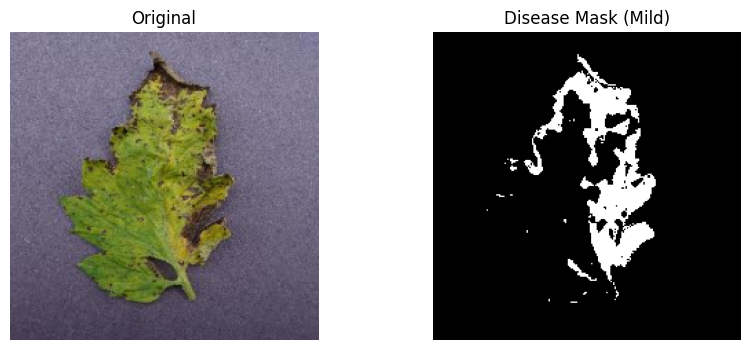

In [23]:
estimate_severity("/content/drive/MyDrive/Final Project Dataset/PlantVillage/Tomato_Septoria_leaf_spot/04840559-16ed-4f17-908b-2048ba83ab80___Keller.St_CG 1780.JPG")

# Thank you